# Figure 2 -- TF weights and TF-set overlaps

Reproduces the ranked TF-weight bar plots (LogFC, LogDHT) and the Venn-diagram
overlap of significant TFs between the inducibility (LogFC) and activity (LogDHT)
models, from the bootstrapped Ridge coefficients produced by `train_model_pipeline.py`.

Expects `../output_files/` to contain `Ridge_coef_bootstrapped_{lfc,dht,etoh}_...647mots.npy`
(one per response variable), produced by running `train_model_pipeline.py` for each of
the `700bp_S0_lfc`, `700bp_S0_dht`, `700bp_S0_etoh` best-model configs (see
`../input_files/best_models_hyperparams_MSE_647mots.json`).

In [1]:
import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import pandas as pd

sys.path.insert(0, os.path.join('..', 'plotting'))
sys.path.insert(0, '.')  # this notebook lives in motif_model/, alongside data_preps.py
from plot_utils import plot_x0s0_ws, return_sig_tfs
from data_preps import Motifs

OUTPUT_DIR = '../output_files'
FIGURES_DIR = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# TF order must match the order train_model_pipeline.py used when it fit the model
# (np.unique of the per-motif TF assignment for the 647-motif / 293-TF library).
with np.load('../input_files/motifs_dict_PWM_pseudo_bg_exp3_JaspHomoLV24_293tf_647mots_LNCaP_aligned.npz') as d:
    motif_pwms = {k: d[k] for k in d.files}
with np.load('../input_files/HOCO_uniprot_to_gene.npz') as d:
    conversion = {k: d[k] for k in d.files}
tfs = np.unique(Motifs(motif_pwms, conversion).mot_tfs)

c:\Users\Hoda Taeb\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Load bootstrapped coefficients for each response variable

In [2]:
POOLING = {'lfc': 'avgpooling', 'dht': 'maxpooling', 'etoh': 'maxpooling'}

def load_coef_bs(output_name, n_mots=647):
    """Find the bootstrapped-coefficient file for a given response variable
    (lfc, dht, or etoh) among train_model_pipeline.py's output files.
    Pinned to the position-independent (bin700bp, S0) best-config pooling
    method per response variable, since multiple grid-search configs can
    otherwise share the same '647mots' suffix."""
    pattern = os.path.join(
        OUTPUT_DIR, f'Ridge_coef_bootstrapped_{output_name}_bin700bp_{POOLING[output_name]}_S0_*{n_mots}mots.npy'
    )
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(
            f"No bootstrapped coefficients found for '{output_name}' matching {pattern}. "
            "Run train_model_pipeline.py for this response variable first."
        )
    if len(matches) > 1:
        raise RuntimeError(f"Ambiguous match for '{output_name}': {matches}")
    return np.load(matches[0])

coef_bs = {output: load_coef_bs(output) for output in ['lfc', 'dht', 'etoh']}

## Figure 2A -- LogFC model weights (inducibility)

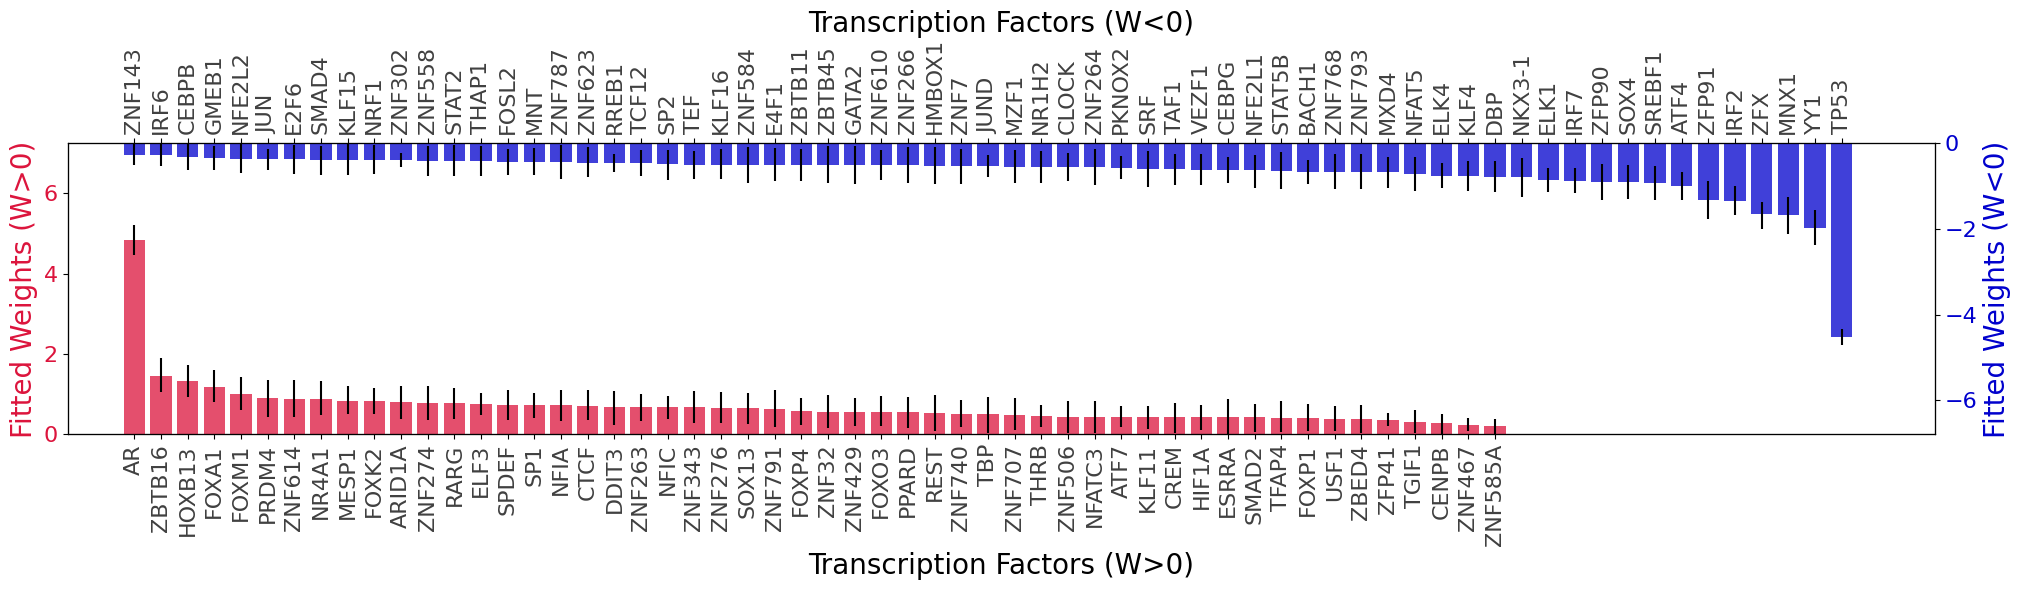

In [3]:
fig = plot_x0s0_ws(coef_bs['lfc'], tfs, CI=95, fig_length_coef=2.5, ylim_coef=0.5,
                    fig_size=6, tick_fontsize=16)
fig.savefig(f'{FIGURES_DIR}/fig2a_logfc_weights.pdf', dpi=200, bbox_inches='tight')
plt.show()

## Figure 2B -- LogDHT model weights (activity), top 40 positive/negative

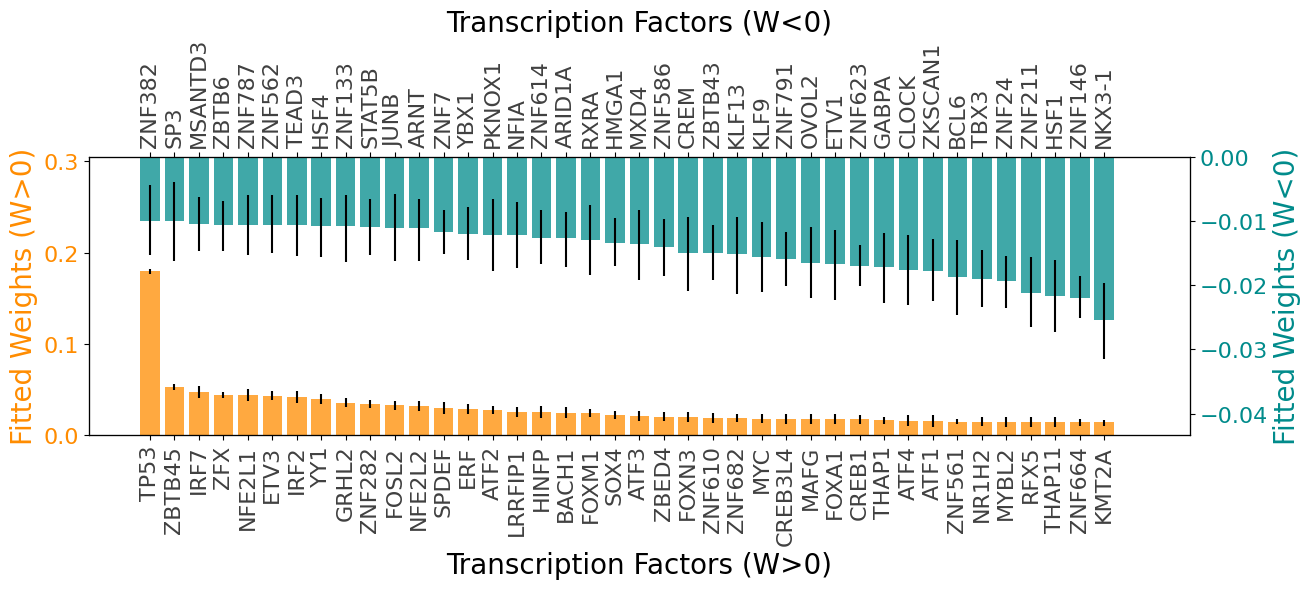

In [4]:
fig = plot_x0s0_ws(coef_bs['dht'], tfs, CI=95, pos_barcolor='#FF8C00', neg_barcolor='#008B8B',
                    ylim_coef=0.7, fig_length_coef=2.7, top_tfs=40, fig_size=6, tick_fontsize=16)
fig.savefig(f'{FIGURES_DIR}/fig2b_logdht_weights_top40.pdf', dpi=200, bbox_inches='tight')
plt.show()

## Figure 2C -- Overlap of significant TFs between LogFC and LogDHT

Exclusive-region counts (each TF counted in exactly one row) across the four groups:
LFC W>0, LFC W<0, DHT W>0, DHT W<0.

In [5]:
import itertools

sig = {}
for output in ['lfc', 'dht', 'etoh']:
    pos, neg = return_sig_tfs(coef_bs[output], tfs, CI=95)
    sig[f'{output}_pos'] = set(pos)
    sig[f'{output}_neg'] = set(neg)

groups_2c = {'LFC+': sig['lfc_pos'], 'LFC-': sig['lfc_neg'], 'DHT+': sig['dht_pos'], 'DHT-': sig['dht_neg']}
group_names_2c = list(groups_2c.keys())

overlap_rows = []
for r in range(1, len(group_names_2c) + 1):
    for combo in itertools.combinations(group_names_2c, r):
        intersection = set.intersection(*(groups_2c[name] for name in combo))
        other_names = [name for name in group_names_2c if name not in combo]
        if other_names:
            intersection -= set.union(*(groups_2c[name] for name in other_names))
        if intersection:
            overlap_rows.append({'Groups': ' & '.join(combo), 'n_TFs': len(intersection),
                                  'TFs': ', '.join(sorted(intersection))})

fig2c_overlap = pd.DataFrame(overlap_rows).sort_values('n_TFs', ascending=False)
fig2c_overlap.to_csv(f'{FIGURES_DIR}/fig2c_overlap_counts.csv', index=False)
fig2c_overlap

,Groups,n_TFs,TFs
2,DHT+,60,"ATF1, ATF2, ATF3, CREB1, CREB3L4, ELF2, ERF, E..."
3,DHT-,51,"ARNT, BCL6, ELF1, ETV1, FOXK1, GABPA, HES6, HM..."
6,LFC- & DHT+,33,"ATF4, BACH1, CEBPB, CEBPG, E4F1, FOSL2, IRF2, ..."
0,LFC+,27,"ATF7, ELF3, FOXK2, FOXP1, FOXP4, HIF1A, HOXB13..."
1,LFC-,16,"ELK1, ELK4, GMEB1, HMBOX1, IRF6, JUN, KLF15, M..."
7,LFC- & DHT-,16,"CLOCK, DBP, E2F6, GATA2, MNT, MXD4, NKX3-1, RR..."
5,LFC+ & DHT-,15,"AR, ARID1A, CREM, CTCF, DDIT3, ESRRA, MESP1, N..."
4,LFC+ & DHT+,10,"CENPB, FOXA1, FOXM1, FOXO3, NFATC3, SPDEF, TGI..."


## Table S2 -- Sign of each TF's weight in the LogFC, LogDHT, and LogEtOH models

One row per TF that is significant (95% CI excludes zero) in at least one of the three
models; columns give the sign of its weight in each model ('+', '-', or 'ns' for not
significant).

In [6]:
def sign_column(output):
    col = pd.Series('ns', index=tfs)
    col[list(sig[f'{output}_pos'])] = '+'
    col[list(sig[f'{output}_neg'])] = '-'
    return col

table_s2 = pd.DataFrame({
    'TF': tfs,
    'LogFC': sign_column('lfc').values,
    'LogDHT': sign_column('dht').values,
    'LogEtOH': sign_column('etoh').values,
})

# Keep only TFs significant in at least one model
table_s2 = table_s2[(table_s2[['LogFC', 'LogDHT', 'LogEtOH']] != 'ns').any(axis=1)]
table_s2 = table_s2.sort_values(['LogFC', 'LogDHT', 'LogEtOH', 'TF'])

table_s2.to_csv(f'{FIGURES_DIR}/table_s2_tf_signs.csv', index=False)
table_s2

,TF,LogFC,LogDHT,LogEtOH
15,CENPB,+,+,+
40,FOXA1,+,+,+
44,FOXM1,+,+,+
46,FOXO3,+,+,+
147,SPDEF,+,+,+
...,...,...,...,...
71,KLF10,ns,ns,+
87,MGA,ns,ns,+
188,ZBTB42,ns,ns,+
261,ZNF605,ns,ns,-


## Figure S2 -- Full-range LogDHT and LogEtOH weights, and their overlap

Same weight-plot and TF-overlap analysis as Figure 2, but showing the LogDHT and LogEtOH
models' full range of significant TFs (no top-40 truncation), and comparing the DHT vs
EtOH significant TF sets directly instead of against LogFC.

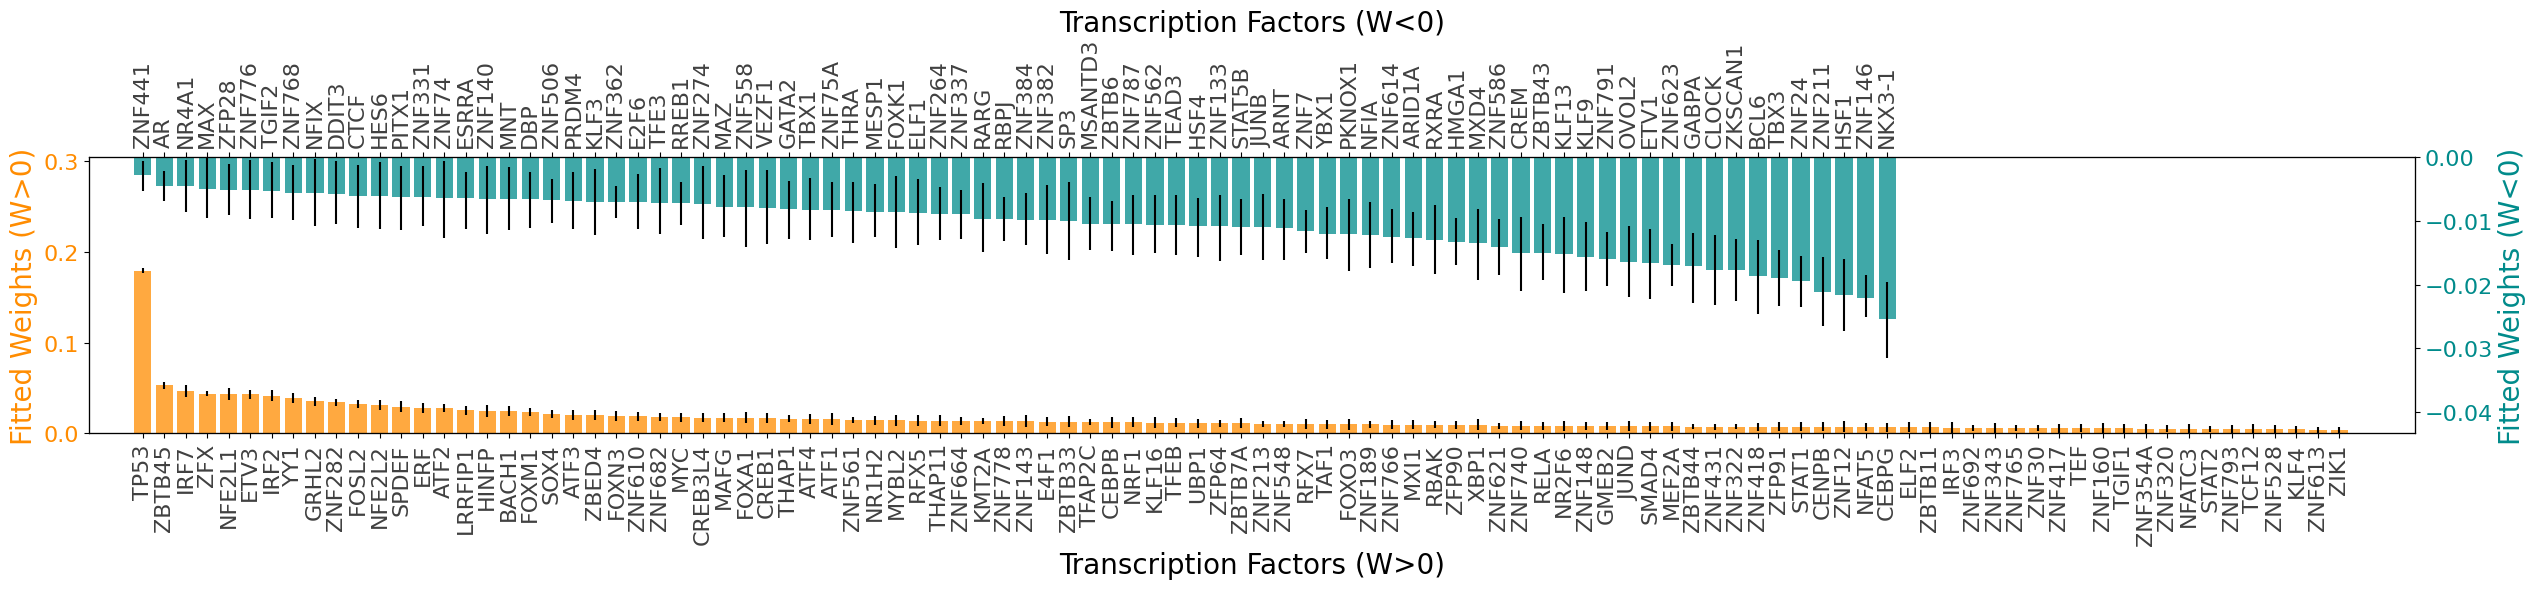

In [15]:
fig = plot_x0s0_ws(coef_bs['dht'], tfs, CI=95, pos_barcolor='#FF8C00', neg_barcolor='#008B8B',
                    ylim_coef=0.7, fig_length_coef=2, fig_size=6, tick_fontsize=16)
fig.savefig(f'{FIGURES_DIR}/figS2a_logdht_weights_full.pdf', dpi=200, bbox_inches='tight')
plt.show()

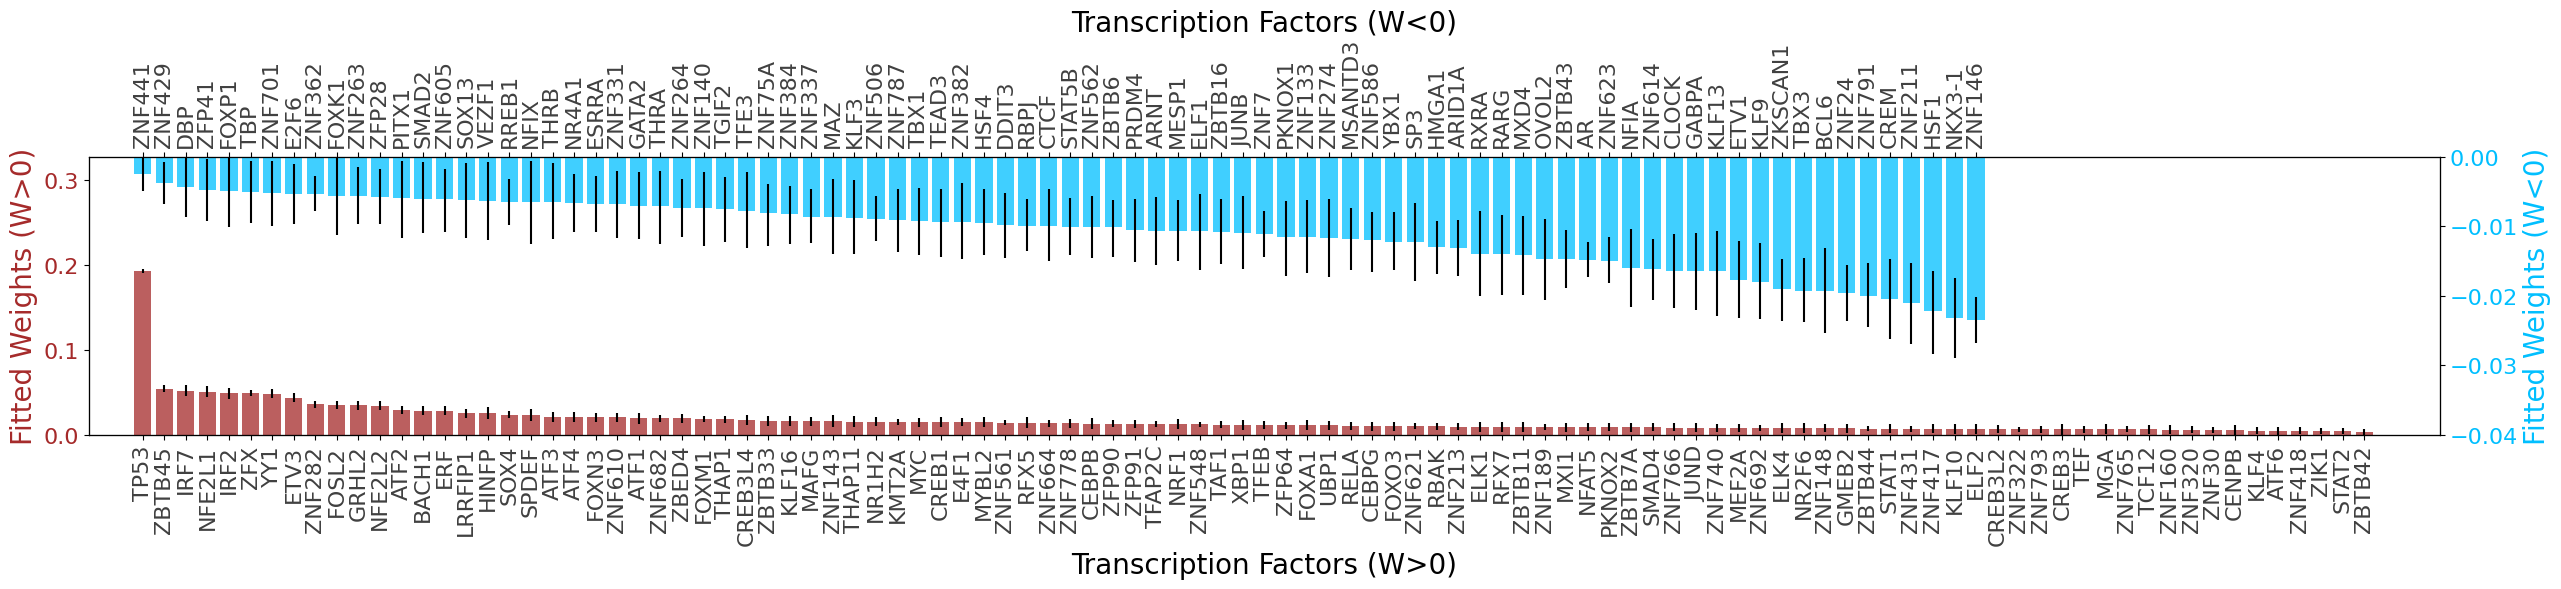

In [16]:
fig = plot_x0s0_ws(coef_bs['etoh'], tfs, CI=95, pos_barcolor='brown', neg_barcolor='deepskyblue',
                    ylim_coef=0.7, fig_length_coef=2, fig_size=6, tick_fontsize=16)
fig.savefig(f'{FIGURES_DIR}/figS2b_logetoh_weights_full.pdf', dpi=200, bbox_inches='tight')
plt.show()

### Overlap of significant TFs between LogDHT and LogEtOH

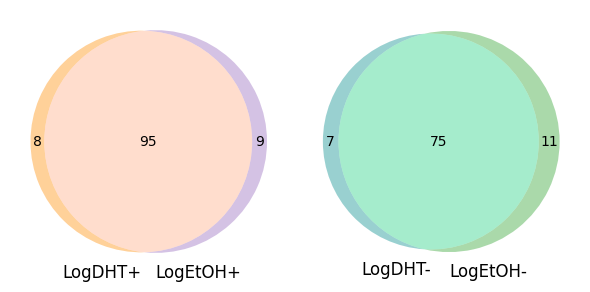

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
venn2([sig['dht_pos'], sig['etoh_pos']], ('LogDHT+', 'LogEtOH+'),
      set_colors=('#FF8C00', '#9467bd'), ax=axes[0])
venn2([sig['dht_neg'], sig['etoh_neg']], ('LogDHT-', 'LogEtOH-'),
      set_colors=('#008B8B', '#2ca02c'), ax=axes[1])
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/figS2c_dht_etoh_overlap_venn.pdf', dpi=200, bbox_inches='tight')
plt.show()

### TFs distinct to LogDHT or LogEtOH

TFs significant in one model's weights but not the other's (the non-overlapping regions
of the venn diagrams above).

In [10]:
dht_only_pos = sig['dht_pos'] - sig['etoh_pos']
etoh_only_pos = sig['etoh_pos'] - sig['dht_pos']
dht_only_neg = sig['dht_neg'] - sig['etoh_neg']
etoh_only_neg = sig['etoh_neg'] - sig['dht_neg']

distinct_rows = (
    [{'TF': tf, 'Distinct_to': 'LogDHT', 'Sign': '+'} for tf in sorted(dht_only_pos)] +
    [{'TF': tf, 'Distinct_to': 'LogEtOH', 'Sign': '+'} for tf in sorted(etoh_only_pos)] +
    [{'TF': tf, 'Distinct_to': 'LogDHT', 'Sign': '-'} for tf in sorted(dht_only_neg)] +
    [{'TF': tf, 'Distinct_to': 'LogEtOH', 'Sign': '-'} for tf in sorted(etoh_only_neg)]
)
table_s2_distinct = pd.DataFrame(distinct_rows)
table_s2_distinct.to_csv(f'{FIGURES_DIR}/figS2d_dht_etoh_distinct_tfs.csv', index=False)
table_s2_distinct

,TF,Distinct_to,Sign
0,IRF3,LogDHT,+
1,NFATC3,LogDHT,+
2,TGIF1,LogDHT,+
3,ZNF12,LogDHT,+
4,ZNF343,LogDHT,+
5,ZNF354A,LogDHT,+
6,ZNF528,LogDHT,+
7,ZNF613,LogDHT,+
8,ATF6,LogEtOH,+
9,CREB3,LogEtOH,+
